## fpocket 200 clustering for ensemble docking (with 5 reps)

In [15]:
# kernel fpocket
import sys
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import mdtraj as md
import MDAnalysis as mda
from MDAnalysis.analysis import align
from MDAnalysis.analysis.rms import rmsd, RMSF
from MDAnalysis import Universe
import MDAnalysis.analysis.pca as pca
from MDAnalysis.coordinates.memory import MemoryReader


from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
# from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, silhouette_score

import nglview as nv


### Load data and select groups
Working with CTD domains of chain A and D.

In [2]:
base = "/biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein"
paths = {f"r{i}": os.path.join(base, f"Run{i}") for i in range(1, 6)}
working_dir = "/biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run1/clustering/allreps_site11"

universes = {}
for rep, path in paths.items():
    gro = os.path.join(path, "md_prot.gro")
    xtc = os.path.join(path, "md_prot_cent_ts100.xtc")
    universes[rep] = mda.Universe(gro, xtc)
    print(f"Loaded {rep}: {gro}, {xtc}")

Loaded r1: /biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run1/md_prot.gro, /biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run1/md_prot_cent_ts100.xtc
Loaded r2: /biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run2/md_prot.gro, /biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run2/md_prot_cent_ts100.xtc
Loaded r3: /biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run3/md_prot.gro, /biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run3/md_prot_cent_ts100.xtc
Loaded r4: /biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run4/md_prot.gro, /biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run4/md_prot_cent_ts100.xtc
Loaded r5: /biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run5/md_prot.gro, /biggin/b240/ball5406/isocitrate_lyase/ICL2/ICL2_apo/fullprotein/Run5/md_prot_cent_ts100.xtc


In [3]:
# Selection definitions
sel_CTD_A     = 'protein and bynum 9054:11750'
sel_CTD_D     = 'protein and bynum 44304:47000'
sel_AD_CTD    = f'{sel_CTD_A} or {sel_CTD_D}'

sel_fp11_A    = '(protein and resid 688 686 684 690 761 726 759 753 and bynum 9054:11750)'
sel_fp11_D    = '(protein and resid 658 660 659 661 680 and bynum 44304:47000)'
sel_fp11_AD   = f'{sel_fp11_A} or {sel_fp11_D}'
sel_fp11_AD_heavy = f'{sel_fp11_AD} and not name H* and not backbone'

# Build dictionaries for each rep
CTD_A     = {}
CTD_D     = {}
AD_CTD    = {}
fp11_AD   = {}
fp11_AD_heavy = {}

for rep, u in universes.items():   # universes["r1"], universes["r2"], ...
    CTD_A[rep]        = u.select_atoms(sel_CTD_A)
    CTD_D[rep]        = u.select_atoms(sel_CTD_D)
    AD_CTD[rep]       = u.select_atoms(sel_AD_CTD)
    fp11_AD[rep]      = u.select_atoms(sel_fp11_AD)
    fp11_AD_heavy[rep]= u.select_atoms(sel_fp11_AD_heavy)


In [ ]:
# Atom selection for interface and non-int resids, only need single run for ref structure
path_to_interface = os.path.join(base,"Run1/clustering/", "chainD_within5A.csv")
interface = pd.read_csv(path_to_interface, index_col=0)
interface.drop_duplicates(inplace=True, subset=['0'])
interface_resnum_str = ' '.join(str(r) for r in interface.iloc[:,0].values)

# Interface selections
sel_int_CTD_A = f'protein and resid {interface_resnum_str} and bynum 9054:11750'
sel_int_CTD_D = f'protein and resid {interface_resnum_str} and bynum 44304:47000'
sel_int_CTD_all = f'protein and resid {interface_resnum_str} and (bynum 44304:47000 or bynum 9054:11750)'
sel_not_int = f'({sel_AD_CTD}) and not ({sel_int_CTD_A} or {sel_int_CTD_D})'
sel_not_int_BB = f'{sel_not_int} and name CA C N O'


### Align domains - all residues not at interface
Align each rep to the all backbone resids that are not involved in the interface of the CTD domains from chains A and D.

In [5]:
# Load real structure PDB
# Note: ref must be a pdb not gro file - affects the output
# Frame to align to:
pdb_frame = os.path.join(working_dir, "6edw_fix.pdb") # full protein 
ref = Universe(pdb_frame)


/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


### Functions for calculating rmsd - compute per rep

In [6]:
def calc_rmsd(universe, reference, selection):
    """
    Calculate RMSD and plot graph
    """
    # Calculate RMSD
    rmsd = mda.analysis.rms.RMSD(universe, reference, selection, superposition= True)
    rmsd.run()

    # Extract results 
    frames = rmsd.results.rmsd[:,0]
    times = rmsd.results.rmsd[:,1]
    rmsd_out = rmsd.results.rmsd[:,2]

    # Plot graph
    plt.plot(times, rmsd_out)
    plt.xlabel("Time (ps)")
    plt.ylabel("Interface RMSD (Ang)")
    plt.grid(True)
    plt.show()

    return 

Calculating RMSD for rep r1 ...


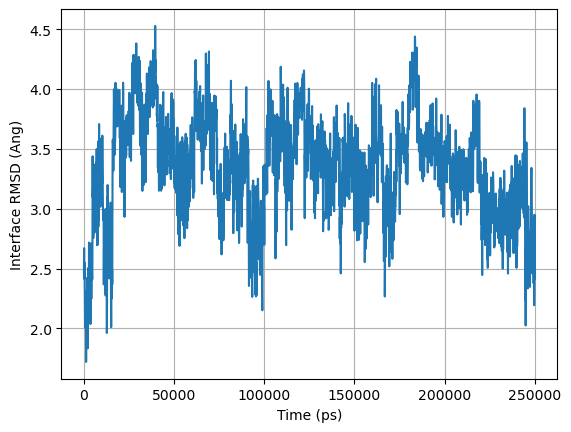

Calculating RMSD for rep r2 ...


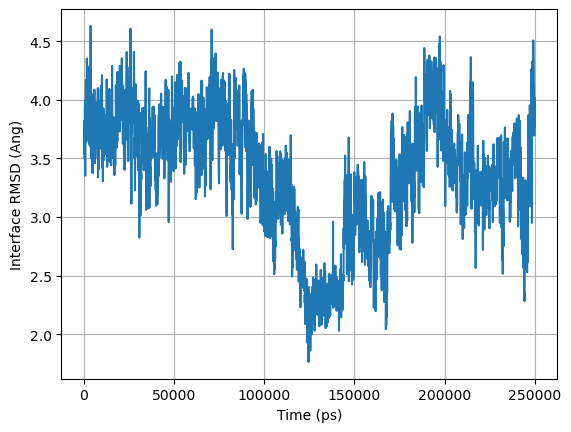

Calculating RMSD for rep r3 ...


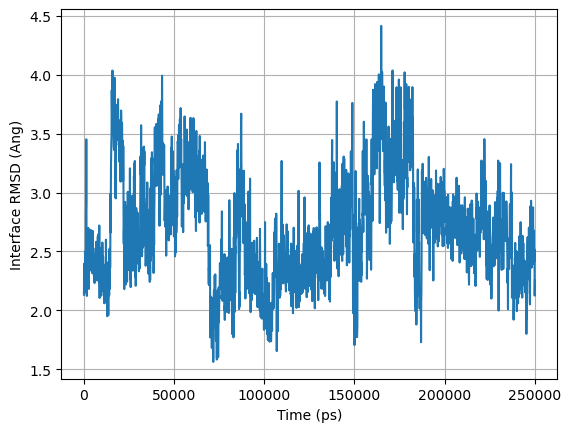

Calculating RMSD for rep r4 ...


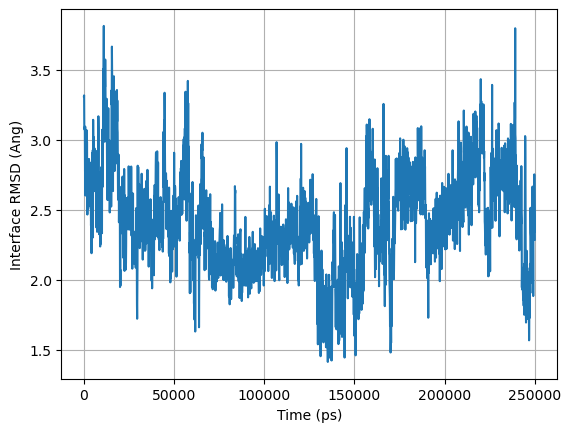

Calculating RMSD for rep r5 ...


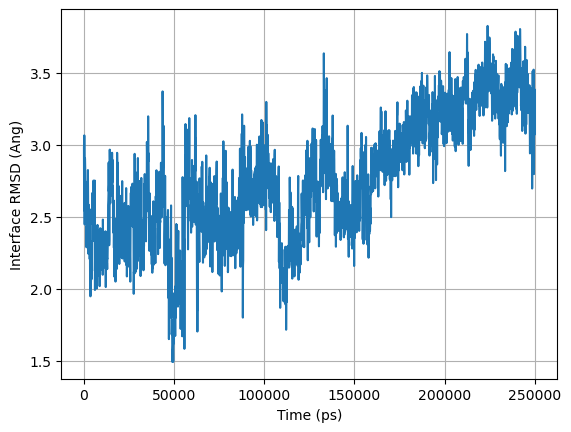

In [76]:
# RMSD 
for rep, u in universes.items():
    print(f'Calculating RMSD for rep {rep} ...')
    calc_rmsd(u, ref, f'{sel_fp11_AD_heavy}')

### Build coordinate vectors and concat reps 
This selects for binding site residues that are heavy atoms and non-backbone

In [ ]:
# Build coordinate matrics and concat reps
# Select heavy atoms only and not backbone of the binding site
sel_fp11_AD_heavy = f'{sel_fp11_AD} and not name H* and not backbone'

# Trajectories and universes
rep_trajs = [("./r1_aligned.pdb", "./r1_aligned.xtc"),
              ("./r2_aligned.pdb", "./r2_aligned.xtc"),
                ("./r3_aligned.pdb", "./r3_aligned.xtc"),
                ("./r4_aligned.pdb", "./r4_aligned.xtc"),
                ("./r5_aligned.pdb", "./r5_aligned.xtc")] # aligned trajectories

coords = []
frame_ids =[]
meta = []

for rep_id, (ref_pdb, ref_traj) in enumerate(rep_trajs):
    uni = Universe(ref_pdb, ref_traj)
    sel_atoms = uni.select_atoms(sel_fp11_AD_heavy)
    print(f'Analysing rep {rep_id+1}')

    for ts in uni.trajectory[1000:2500]:
        coords.append(sel_atoms.positions.flatten())
        frame_ids.append(uni.trajectory.frame)
        meta.append([rep_id, ts.time])

coords_all = np.vstack(coords)
print (f'Matrix formed and concatenated reps - matrix with shape {np.shape(coords_all)}')

# For MDA PCA - need to reshape flattened concatenated numpy array
# Use the ref_pdb as the reference topology file 


# --- Variables from your previous steps ---
# coords_all: The (N_frames_total, 3 * N_atoms_selected) NumPy array.
# N_frames_total: coords_all.shape[0]

# 1. Get the Topology Reference from the Alignment PDB
ref = Universe(pdb_frame)

# Select the *topology* for the atoms corresponding to your coords_all array
sel_atoms_ref = ref.select_atoms(sel_fp11_AD_heavy)
N_atoms_selected = len(sel_atoms_ref)

print(f"Reference PDB contains {N_atoms_selected} atoms for your selection.")

# Sanity Check (Crucial)
if N_atoms_selected * 3 != coords_all.shape[1]:
    raise ValueError(f"Atom count mismatch! Selection gives {N_atoms_selected*3} coordinates, but coords_all has {coords_all.shape[1]}.")

# 2. Reshape the Concatenated Array
# Convert (N_frames, N_atoms * 3) -> (N_frames, N_atoms, 3)
N_frames_total = coords_all.shape[0]
traj_coords_3D = coords_all.reshape((N_frames_total, N_atoms_selected, 3))

# 3. Create the MDAnalysis Universe for PCA
# a. Use mda.Merge to create a universe containing *only* the selected atom topology
u_pca = mda.Merge(sel_atoms_ref)

# b. Load the 3D NumPy array as the trajectory using MemoryReader
u_pca.load_new(traj_coords_3D, format=MemoryReader)

print(f"PCA Universe ready: {len(u_pca.atoms)} atoms and {len(u_pca.trajectory)} frames.")




/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


Analysing rep 1
Analysing rep 2
Analysing rep 3
Analysing rep 4
Analysing rep 5
Matrix formed and concatenated reps - matrix with shape (7500, 168)
Reference PDB contains 56 atoms for your selection.
PCA Universe ready: 56 atoms and 7500 frames.


In [24]:
np.shape(coords_all)

(7500, 168)

Build coord matrix for C alpha atoms only for PCA to see lif we can capture 'breathing' motion of the pocket

In [28]:
sel_fp11_AD_CA = f'{sel_fp11_AD} and name CA'

# Trajectories and universes
rep_trajs = [("./r1_aligned.pdb", "./r1_aligned.xtc"),
              ("./r2_aligned.pdb", "./r2_aligned.xtc"),
                ("./r3_aligned.pdb", "./r3_aligned.xtc"),
                ("./r4_aligned.pdb", "./r4_aligned.xtc"),
                ("./r5_aligned.pdb", "./r5_aligned.xtc")] # aligned trajectories

coords_CA = []
frame_ids_CA =[]
meta_CA = []

for rep_id, (ref_pdb, ref_traj) in enumerate(rep_trajs):
    uni = Universe(ref_pdb, ref_traj)
    sel_atoms = uni.select_atoms(sel_fp11_AD_CA)
    print(f'Analysing rep {rep_id+1}')

    for ts in uni.trajectory[1000:2500]:
        coords_CA.append(sel_atoms.positions.flatten())
        frame_ids_CA.append(uni.trajectory.frame)
        meta_CA.append([rep_id, ts.time])

coords_all_CA = np.vstack(coords_CA)
print (f'Matrix formed and concatenated reps - matrix with shape {np.shape(coords_all_CA)}')

# For MDA PCA - need to reshape flattened concatenated numpy array

# --- Variables from your previous steps ---
# coords_all: The (N_frames_total, 3 * N_atoms_selected) NumPy array.
# N_frames_total: coords_all.shape[0]

# 1. Get the Topology Reference from the Alignment PDB
ref = Universe(pdb_frame)

# Select the *topology* for the atoms corresponding to your coords_all array
sel_atoms_ref_CA = ref.select_atoms(sel_fp11_AD_CA)
N_atoms_selected_CA = len(sel_atoms_ref_CA)

print(f"Reference PDB contains {N_atoms_selected_CA} atoms for your selection.")



# Sanity Check (Crucial)
if N_atoms_selected_CA * 3 != coords_all_CA.shape[1]:
    raise ValueError(f"Atom count mismatch! Selection gives {N_atoms_selected_CA*3} coordinates, but coords_all has {coords_all_CA.shape[1]}.")

# 2. Reshape the Concatenated Array
# Convert (N_frames, N_atoms * 3) -> (N_frames, N_atoms, 3)
N_frames_total_CA = coords_all_CA.shape[0]
traj_coords_3D_CA = coords_all_CA.reshape((N_frames_total_CA, N_atoms_selected_CA, 3))

# 3. Create the MDAnalysis Universe for PCA
# a. Use mda.Merge to create a universe containing *only* the selected atom topology
u_pca_CA = mda.Merge(sel_atoms_ref_CA)

# b. Load the 3D NumPy array as the trajectory using MemoryReader
u_pca_CA.load_new(traj_coords_3D_CA, format=MemoryReader)

print(f"PCA Universe ready: {len(u_pca_CA.atoms)} atoms and {len(u_pca_CA.trajectory)} frames.")


/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


Analysing rep 1
Analysing rep 2
Analysing rep 3
Analysing rep 4
Analysing rep 5
Matrix formed and concatenated reps - matrix with shape (7500, 39)
Reference PDB contains 13 atoms for your selection.
PCA Universe ready: 13 atoms and 7500 frames.


### PCA of coodinates on all reps together

In [ ]:
# # Function to perform PCA 
# def do_PCA(coords, n_PCA_components):
#     """
#     Perform PCA to reduce noise/ dimensionality

#     Inputs:
#         coords: Coordinates of matrix, after alignmnet and flattening 
#         n_PCA_components: Specify number of PCA components
    
#     """

#     if coords.shape[0]<2:
#         raise SystemExit ("Not enough frames for clustering")
    
#     # Calculate PCA
#     n_pcas = min(n_PCA_components, coords.shape[0], coords.shape[1])
#     pca = PCA(n_components=n_pcas)
#     Xpca = pca.fit_transform(coords)
#     print ("PCA complete") 

#     # Plot
#     plt.scatter(Xpca[:,1], Xpca[:,2],marker='.')
#     plt.xlabel("PCA 1")
#     plt.ylabel("PCA 2")
#     plt.show()

#     return Xpca 

# Do PCA on all reps
# Xpca_fp11_CA = do_PCA(coords_CA_only,10)
# Xpca_fp11 = do_PCA(coords_all, 10)

In [30]:
# MDAnalysis implementation of PCA 

def do_MDA_PCA(u, selection_string, n_PCA_components):
    """
    Perform PCA on a specified AtomGroup selection using MDAnalysis.

    Inputs:
        u: MDAnalysis Universe object (must have trajectory loaded).
        selection_string: Atom selection string (e.g., 'resid 10-20 and name CA').
        n_PCA_components: Specify number of PCA components to keep.

    Returns:
        pca_analysis: The MDAnalysis PCA object containing components, mean, and variance.
        Xpca: The transformed trajectory (projections onto the components).
        selection: The MDAnalysis AtomGroup used for the PCA.
    """
    # 1. Select Atoms
    # selection = u.select_atoms(selection_string)
    selection = u.atoms
    print(f"PCA on {len(selection)} atoms")

    # 2. Run PCA Analysis
    # NOTE: MDAnalysis's PCA aligns the coordinates to the mean structure internally.
    pca_analysis = pca.PCA(u, selection=selection_string).run()
    
    # Check number of components
    n_pcas = min(n_PCA_components, pca_analysis.n_components)
    
    # 3. Transform (Project) the Trajectory
    # Xpca will be a (n_frames, n_components) array of projections
    Xpca = pca_analysis.transform(selection, n_components=n_pcas)
    print("PCA complete.")

    # Total and % variance
    total_variance = np.sum(pca_analysis.variance)
    percent_var_pc1 = (pca_analysis.variance[0] / total_variance) * 100
    percent_var_pc2 = (pca_analysis.variance[1] / total_variance) * 100

    # 4. Plot (PC1 vs PC2)
    plt.scatter(Xpca[:, 0], Xpca[:, 1], marker='.', alpha=0.5)
    plt.xlabel(f"PC 1 ({percent_var_pc1:.2f}% variance)")
    plt.ylabel(f"PC 2 ({percent_var_pc2:.2f}% variance)")
    plt.show()

    # Plot cumulative variance
    plt.plot(pca_analysis.cumulated_variance[:n_PCA_components])
    plt.xlabel('Principle Component')
    plt.ylabel('Cumulative variance')
    plt.show()

    return pca_analysis, Xpca, selection


PCA on 56 atoms
PCA complete.


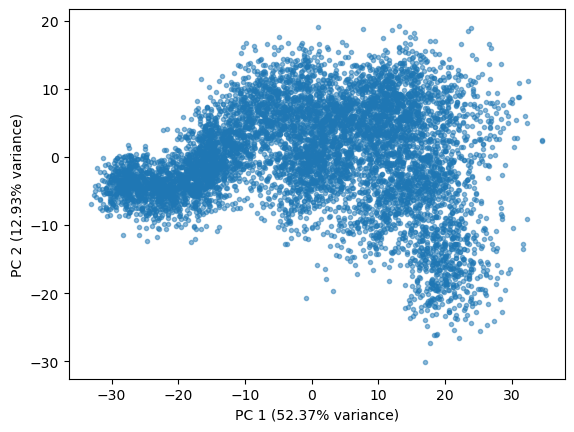

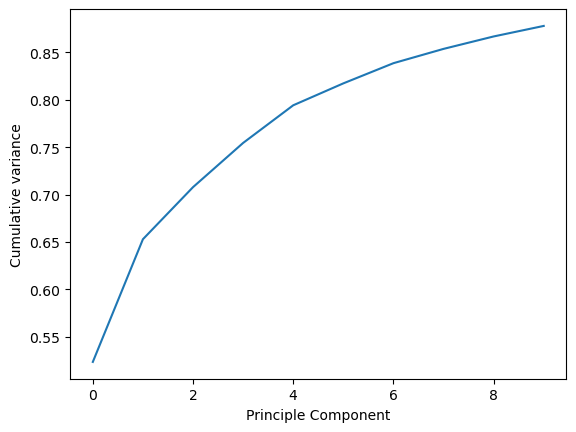

In [37]:
mda_Xpca = do_MDA_PCA(u_pca, sel_fp11_AD_heavy, 10)

PCA on 13 atoms
PCA complete.


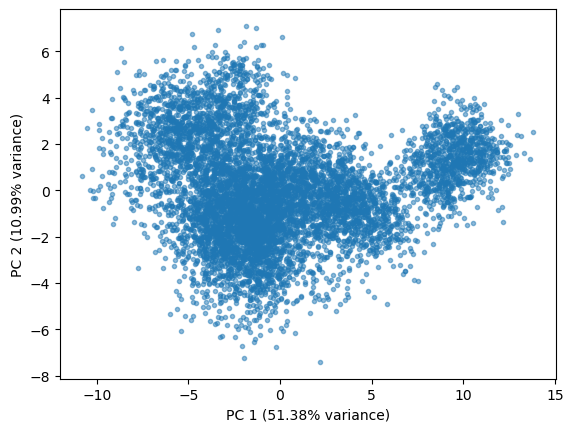

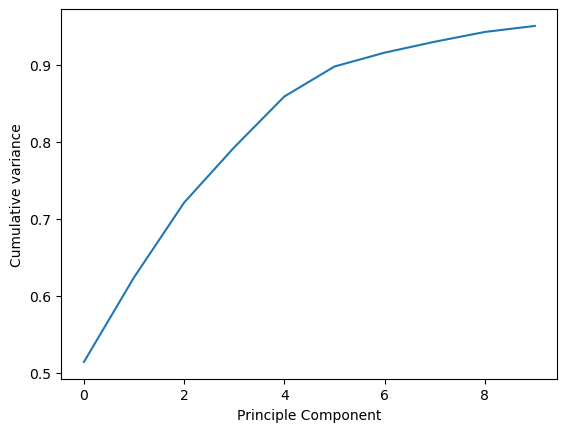

In [38]:
# PCA on CA atoms only of the binding site
mda_Xpca_CA = do_MDA_PCA(u_pca_CA, sel_fp11_AD_CA, 10)

## PC1

In [32]:
# Projection of frames onto PCs
# pca_analysis = mda_Xpca[0]
# Xpca = mda_Xpca[1]
# selection = mda_Xpca[2]

# Select atoms for projection
atoms_pca = u_pca

# Transform atom group over every component
transformed = mda_Xpca[0].transform(atoms_pca, n_components=3)
transformed.shape

# Generate projected coordinates for PC1
pc1 = mda_Xpca[0].p_components[:, 0]
trans1 = transformed[:, 0]
projected = np.outer(trans1, pc1) + mda_Xpca[0].mean.flatten()
coordinates = projected.reshape(len(trans1), -1, 3)

# Create new universe to visualise movement over PC1
proj1 = mda.Merge(atoms_pca.atoms)
proj1.load_new(coordinates, order='fac')


/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/analysis/pca.py:350: DeprecationWarning: The `p_components` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.p_components` instead.
  warnings.warn(wmsg, DeprecationWarning)


<Universe with 56 atoms>

In [42]:
import nglview as nv

# Atoms PC1 binding site are component 
view = nv.show_mdanalysis(proj1.atoms)
view.clear_representations()
view.add_representation('spacefill', selection='all', component=0)
view.center()
# view.player.parameters={'step':10}


ref_view = view.add_component(ref.atoms)


# view.add_representation('cartoon', selection='all', component=ref_view, color='red')

view

NGLWidget(max_frame=7499)

In [40]:
# Visualising CA atoms only for PC1
# Select atoms for projection
atoms_pca_CA = u_pca_CA

# Transform atom group over every component
transformed_CA = mda_Xpca_CA[0].transform(atoms_pca_CA, n_components=3)
transformed_CA.shape

# Generate projected coordinates for PC1
pc1_CA = mda_Xpca_CA[0].p_components[:, 0]
trans1_CA = transformed[:, 0]
projected_CA = np.outer(trans1_CA, pc1_CA) + mda_Xpca_CA[0].mean.flatten()
coordinates_CA = projected_CA.reshape(len(trans1_CA), -1, 3)

# Create new universe to visualise movement over PC1
proj1_CA = mda.Merge(atoms_pca_CA.atoms)
proj1_CA.load_new(coordinates_CA, order='fac')

/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/analysis/pca.py:350: DeprecationWarning: The `p_components` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.p_components` instead.
  warnings.warn(wmsg, DeprecationWarning)


<Universe with 13 atoms>

In [41]:
# visualise CA only PC1

# Atoms PC1 binding site are component 
view = nv.show_mdanalysis(proj1_CA.atoms)
view.clear_representations()
view.add_representation('spacefill', selection='all', component=0)
view.center()
# view.player.parameters={'step':10}


ref_view = view.add_component(ref.atoms)


# view.add_representation('cartoon', selection='all', component=ref_view, color='red')

view

NGLWidget(max_frame=7499)

### PC2

In [34]:
# Select atoms for projection
atoms_pca = u_pca

# Transform atom group over every component
transformed = mda_Xpca[0].transform(atoms_pca, n_components=3)
transformed.shape

# Generate projected coordinates for PC2
pc2 = mda_Xpca[0].p_components[:, 1]
trans2 = transformed[:, 1]
projected = np.outer(trans2, pc2) + mda_Xpca[0].mean.flatten()
coordinates = projected.reshape(len(trans2), -1, 3)

# Create new universe to visualise movement over PC2
proj2 = mda.Merge(atoms_pca.atoms)
proj2.load_new(coordinates, order='fac')


/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/analysis/pca.py:350: DeprecationWarning: The `p_components` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.p_components` instead.
  warnings.warn(wmsg, DeprecationWarning)


<Universe with 56 atoms>

In [35]:
# Visualise PC2 projection
# Atoms PC1 binding site are component 
view2 = nv.show_mdanalysis(proj2.atoms)
view2.clear_representations()
view2.add_representation('spacefill', selection='all', component=0)
view2.center()
# view.player.parameters={'step':10}


ref_view = view2.add_component(ref.atoms)
view2

NGLWidget(max_frame=7499)

In [96]:
# # Calculate cumulative overlap in PC subspace
### Use cumulative overlap to compare two different PC spaces e.g. PC1 of heavy, non-BB atoms and PC1 of CA atoms only 
### Overlap close to 1 --> highly correlated
### Overlap close to 0 --> uncorrelated, local, decoupled motion
# --- so use this when we get run PCA on  CA atom only.


# PC1_overlap = mda_Xpca[0].cumulative_overlap (other=mda_Xpca[0],i=0, n_components=3)
# print("-" * 50)
# print("Cumulative Overlap (Subspace Comparison)")
# print(f"Overlap of PC1 (Test) onto PC1-PC3 Subspace (Reference): {PC1_overlap:.4f}")



In [44]:
# Select atoms for projection
atoms_pca_CA = u_pca_CA

# Transform atom group over every component
transformed_CA = mda_Xpca_CA[0].transform(atoms_pca_CA, n_components=3)
transformed_CA.shape

# Generate projected coordinates for PC2
pc2_CA = mda_Xpca_CA[0].p_components[:, 1]
trans2_CA = transformed_CA[:, 1]
projected_CA = np.outer(trans2_CA, pc2_CA) + mda_Xpca_CA[0].mean.flatten()
coordinates_CA = projected_CA.reshape(len(trans2_CA), -1, 3)

# Create new universe to visualise movement over PC2
proj2_CA = mda.Merge(atoms_pca_CA.atoms)
proj2_CA.load_new(coordinates_CA, order='fac')

/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/analysis/pca.py:350: DeprecationWarning: The `p_components` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.p_components` instead.
  warnings.warn(wmsg, DeprecationWarning)


<Universe with 13 atoms>

In [45]:
# Visualise PC2 projection
# Atoms PC1 binding site are component 
view2 = nv.show_mdanalysis(proj2_CA.atoms)
view2.clear_representations()
view2.add_representation('spacefill', selection='all', component=0)
view2.center()
# view.player.parameters={'step':10}


ref_view = view2.add_component(ref.atoms)
view2

NGLWidget(max_frame=7499)

### Try PCA on pairwise Calphas

PCA on 56 atoms
PCA complete.


/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/analysis/pca.py:360: DeprecationWarning: The `variance` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.variance` instead.
  warnings.warn(wmsg, DeprecationWarning)


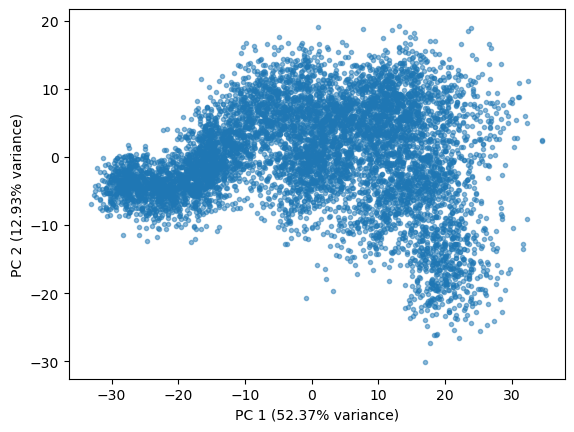

/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/analysis/pca.py:370: DeprecationWarning: The `cumulated_variance` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.cumulated_variance` instead.
  warnings.warn(wmsg, DeprecationWarning)


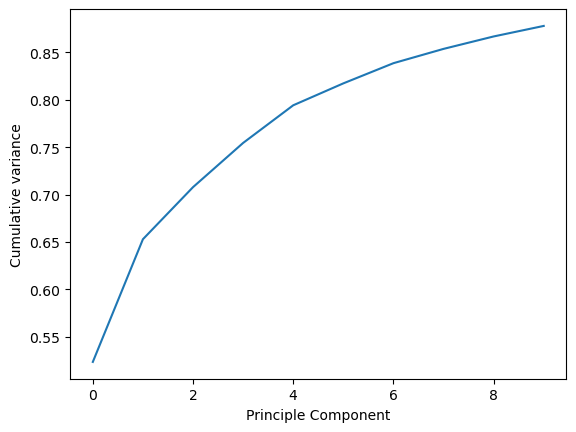

In [101]:
# sel_fp11_AD_CA = f'{sel_fp11_AD} and name CA'

# # Trajectories and universes
# rep_trajs = [("./r1_aligned.pdb", "./r1_aligned.xtc"),
#               ("./r2_aligned.pdb", "./r2_aligned.xtc"),
#                 ("./r3_aligned.pdb", "./r3_aligned.xtc"),
#                 ("./r4_aligned.pdb", "./r4_aligned.xtc"),
#                 ("./r5_aligned.pdb", "./r5_aligned.xtc")] # aligned trajectories

# coords_CA = []
# frame_ids_CA =[]
# meta_CA = []

# for rep_id, (ref_pdb, ref_traj) in enumerate(rep_trajs):
#     uni = Universe(ref_pdb, ref_traj)
#     sel_atoms = uni.select_atoms(sel_fp11_AD_CA)
#     print(f'Analysing rep {rep_id+1}')

#     for ts in uni.trajectory[1000:2500]:
#         coords_CA.append(sel_atoms.positions.flatten())
#         frame_ids_CA.append(uni.trajectory.frame)
#         meta_CA.append([rep_id, ts.time])

# coords_CA_only = np.vstack(coords_CA)
# print (f'Matrix formed and concatenated reps - matrix with shape {np.shape(coords_CA_only)}')

mda_Xpca_CA = do_MDA_PCA(u_pca, sel_fp11_AD_CA, 10)

### Cluster (Kmeans) and medoid calculation 

In [46]:
# Clustering functions
# k_clusters=10 
path_to_cluster = os.path.join(working_dir)

def eval_KMeans(x, k_clusters, r):
    """
    Fit KMeans to data

    Inputs:
        x: Xpca data 
        k_clusters: number of clusters to form/ centroids
        r: random state
    """
    kmeans = KMeans(n_clusters=k_clusters, random_state=r)
    kmeans.fit(x)
    return kmeans.inertia_

# Use elbow method to pick suitable number of clusters
def elbow_KMeans(x, max_k, r=42):
    """Perform elbow method to obtain optimal number of clusters"""

    within_cluster_vars = [eval_KMeans(x,k,r) for k in range(1, max_k +1)]
    plt.plot(range(1,max_k+1), within_cluster_vars)
    plt.xlabel('K')
    plt.ylabel('Inertia')
    plt.show()

def scatter_kmeans(x, k_clusters, r):
    """Scatter plot the KMeans clusters
       Inputs:
        x: Xpca data
        k_clusters: number of clusters to cluster into
        r: random state
    """
    
    kmeans = KMeans(n_clusters=k_clusters, init='k-means++', random_state=r )
    y_pred = kmeans.fit_predict(x)

    # Plot
    # colours='rbgcmy'
    # colours = plt.cm.get_cmap('tab20', k_clusters)  # or 'tab10'
    cmap = plt.get_cmap('tab10' if k_clusters <= 10 else 'tab20', k_clusters)
    colours = cmap(np.arange(k_clusters))          # RGBA array of length k

    for c in range(k_clusters):
        plt.scatter(x[y_pred == c, 0], x[y_pred==c, 1], c=colours[c], label='Clusters{}'.format(c), marker='.')
        plt.scatter(kmeans.cluster_centers_[c,0], kmeans.cluster_centers_[c,1], marker='x', c='black')
        plt.xlabel('PC1')
        plt.ylabel('PC2')
    # score = round(silhouette_score(x, kmeans.labels_, metric='euclidean'), 2)
    plt.show()


    cluster_centroids={}
    medoid_rows=[]
    
    for me in range(k_clusters):
        indexes = np.where(y_pred == me)[0]
        centroid = x[indexes].mean(axis=0)
        cluster_centroids[c] = centroid 

        # medoid in PCA space
        dist = np.linalg.norm(x[indexes] - centroid, axis=1)
        medoid_row = indexes[np.argmin(dist)]
        medoid_rows.append(medoid_row)
    print (f'Medoid rows from concat reps matrix {medoid_rows}')

    # Write medoid structures from correct rep 
    for row in medoid_rows:
        rep_id, frame_id = meta[row]          # make sure frame_id is 0-based for that rep
        top, traj = rep_trajs[rep_id]
        u = mda.Universe(top, traj)
    
        try:
            u.trajectory[int(frame_id/100)]            # move to the medoid frame
        except IndexError:
            u.trajectory[int(frame_id/100)-1]          # if your meta uses 1-based indices

        # Save medoid frames
        output_name = f"medoid_cluster{y_pred[row]}_rep{rep_id}_frame{frame_id}.pdb"
        with mda.Writer(output_name) as W:    # safer writer context
            W.write(u.atoms)
        print("Wrote structure", output_name)


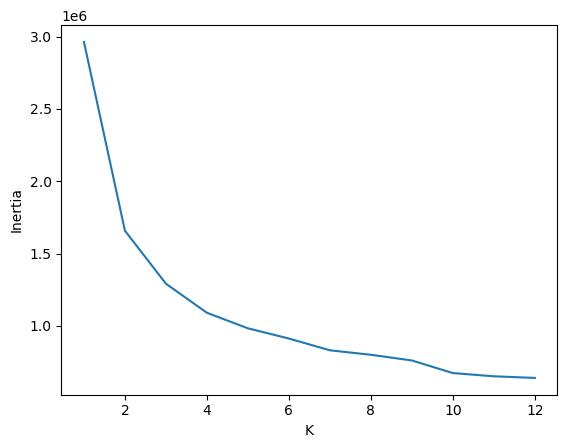

In [47]:
# Evaluate kmeans and plot elbow 
eval_KMeans(Xpca_fp11, 12, 42)
elbow_KMeans(Xpca_fp11,12)

/tmp/ipykernel_6391/3025692842.py:46: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x[y_pred == c, 0], x[y_pred==c, 1], c=colours[c], label='Clusters{}'.format(c), marker='.')


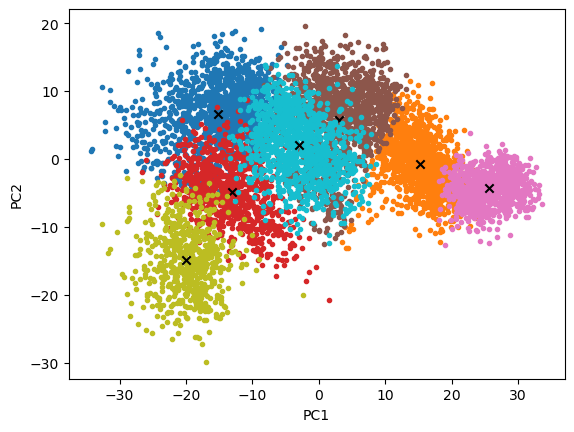

Medoid rows from concat reps matrix [2914, 5599, 349, 5337, 7466, 886, 3022]


/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "
/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'elements' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn("Found no information for attr: '{}'"


Wrote structure medoid_cluster0_rep1_frame241400.0.pdb
Wrote structure medoid_cluster1_rep3_frame209900.0.pdb
Wrote structure medoid_cluster2_rep0_frame134900.0.pdb
Wrote structure medoid_cluster3_rep3_frame183700.0.pdb
Wrote structure medoid_cluster4_rep4_frame246600.0.pdb
Wrote structure medoid_cluster5_rep0_frame188600.0.pdb
Wrote structure medoid_cluster6_rep2_frame102200.0.pdb


In [93]:
fp11_ypred = scatter_kmeans(Xpca_fp11, 7, 42)

DBSCAN found 9 clusters (+ noise)


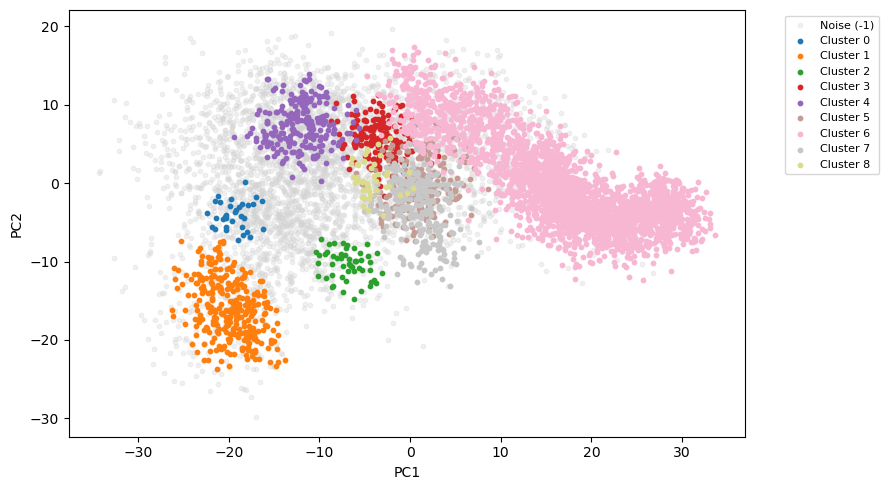

In [57]:
# Try DBSCAN

from sklearn.cluster import DBSCAN

# Xpca_fp11 is your PCA-transformed coordinates
X = Xpca_fp11[:, :10]   # example: first 10 PCs

# Run DBSCAN
# eps = neighborhood radius (tune this!)
# min_samples = how many neighbors to form a dense region
db = DBSCAN(eps=5.5, min_samples=30).fit(X)
labels = db.labels_   # -1 = noise, 0..N = cluster IDs

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"DBSCAN found {n_clusters} clusters (+ noise)")

# Plot in PC1 vs PC2 for visualization
plt.figure(figsize=(9,5))
unique_labels = set(labels)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))    

# plot noise first (underneath)
noise = labels == -1
if noise.any():
    plt.scatter(Xpca_fp11[noise, 0], Xpca_fp11[noise, 1],
                c='lightgrey', s=10, alpha=0.3, zorder=1, label='Noise (-1)')

# then plot the real clusters
for lbl, col in zip([l for l in unique_labels if l != -1], colors):
    mask = labels == lbl
    plt.scatter(Xpca_fp11[mask, 0], Xpca_fp11[mask, 1],
                c=[col], s=10, zorder=2, label=f'Cluster {lbl}')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


In [120]:
# Using HDBSCAN 

import hdbscan

def hdbscan_plot_pca(Xpca, n_pcs_for_cluster=10, min_cluster_size=200, min_samples=None):
    """
    Xpca: np.ndarray of shape (n_samples, n_pcs)  (PC scores; columns are PCs)
    n_pcs_for_cluster: how many PCs to use for clustering (use more than 2)
    min_cluster_size: ~ 0.5–2% of n_samples is a good start
    min_samples: None -> defaults to min_cluster_size; or set ~ 0.3–0.7 * min_cluster_size
    """
    X = np.asarray(Xpca)
    Xc = X[:, :n_pcs_for_cluster]

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric='euclidean',
        cluster_selection_method='eom', # standard
        prediction_data=True
    ).fit(Xc)

    labels = clusterer.labels_          # -1 = noise
    probs  = clusterer.probabilities_   # membership strength [0..1]

    # --- Plot PC1 vs PC2 ---
    fig, ax = plt.subplots(figsize=(8,5))

    # 1) plot noise UNDERNEATH (light grey, low alpha, low zorder)
    noise = labels == -1
    if noise.any():
        ax.scatter(X[noise, 0], X[noise, 1],
                   s=8, c='lightgrey', alpha=0.25, zorder=1, label='noise (-1)')

    # 2) plot clusters on top, coloured
    uniq = [l for l in np.unique(labels) if l != -1]
    cmap = plt.get_cmap('tab20', len(uniq) if len(uniq) > 0 else 1)

    medoid_indices = {}
    for i, lbl in enumerate(uniq):
        m = labels == lbl
        # Optional: weight alpha by membership probability so fuzzy points look lighter
        alpha_vals = 0.25 + 0.75*probs[m]   # map prob 0..1 -> 0.25..1.0

        ax.scatter(X[m, 0], X[m, 1],
                   s=10, color=cmap(i), alpha=None, zorder=2, label=f'C{lbl}')

        # mark a medoid-like representative (closest to cluster mean in the space we clustered in)
        cluster_pts = Xc[m]
        centroid = cluster_pts.mean(axis=0)
        local_idx = np.argmin(np.linalg.norm(cluster_pts - centroid, axis=1))
        global_idx = np.flatnonzero(m)[local_idx]
        medoid_indices[lbl] = global_idx
        ax.scatter(X[global_idx, 0], X[global_idx, 1],
                   marker='x', s=60, color='black', zorder=3)

    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
    plt.tight_layout()


    # --- Calculate and save medoid frames for each cluster ---
    medoid_indices = {}
    for i, lbl in enumerate(uniq):
        m = labels == lbl
        cluster_pts = Xc[m]
        centroid = cluster_pts.mean(axis=0)
        local_idx = np.argmin(np.linalg.norm(cluster_pts - centroid, axis=1))
        global_idx = np.flatnonzero(m)[local_idx]
        medoid_indices[lbl] = global_idx

    # Save medoid frames using meta and rep_trajs
    for lbl, row in medoid_indices.items():
        rep_id, frame_id = meta[row]  # meta[row] should be [rep_id, ts.time]
        top, traj = rep_trajs[rep_id]
        u = mda.Universe(top, traj)
        try:
            u.trajectory[int(frame_id/100)]  # adjust if needed for your frame indexing
        except IndexError:
            u.trajectory[int(frame_id/100)-1] # if metadata uses 1-based indices
        output_name = f"medoid_cluster{lbl}_rep{rep_id}_frame{frame_id}.pdb"
        with mda.Writer(output_name) as W:
            W.write(u.atoms)
        print(f"Wrote structure {output_name}")



/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "
/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'elements'

Wrote structure medoid_cluster0_rep1_frame235200.0.pdb
Wrote structure medoid_cluster1_rep0_frame134900.0.pdb
Wrote structure medoid_cluster2_rep0_frame197200.0.pdb
Wrote structure medoid_cluster3_rep1_frame140400.0.pdb
Wrote structure medoid_cluster4_rep2_frame136100.0.pdb
Wrote structure medoid_cluster5_rep3_frame100500.0.pdb
Wrote structure medoid_cluster6_rep4_frame140600.0.pdb


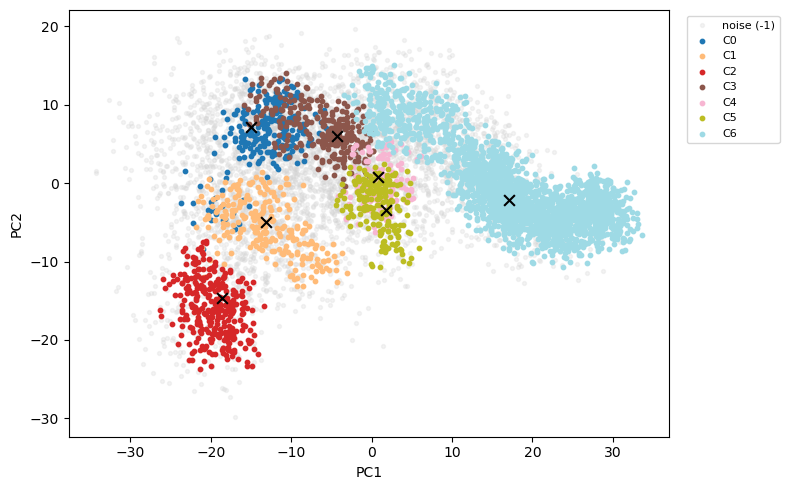

In [141]:
hdbscan_plot_pca(Xpca_fp11, n_pcs_for_cluster=10, min_cluster_size=40, min_samples=None)


/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "
/biggin/b240/ball5406/anaconda3/envs/fpocket/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'elements'

Wrote structure medoid_cluster0_rep0_frame114700.0.pdb
Wrote structure medoid_cluster1_rep1_frame138300.0.pdb
Wrote structure medoid_cluster2_rep4_frame125600.0.pdb
Wrote structure medoid_cluster3_rep3_frame141000.0.pdb
Wrote structure medoid_cluster4_rep2_frame111900.0.pdb
Wrote structure medoid_cluster5_rep3_frame100500.0.pdb


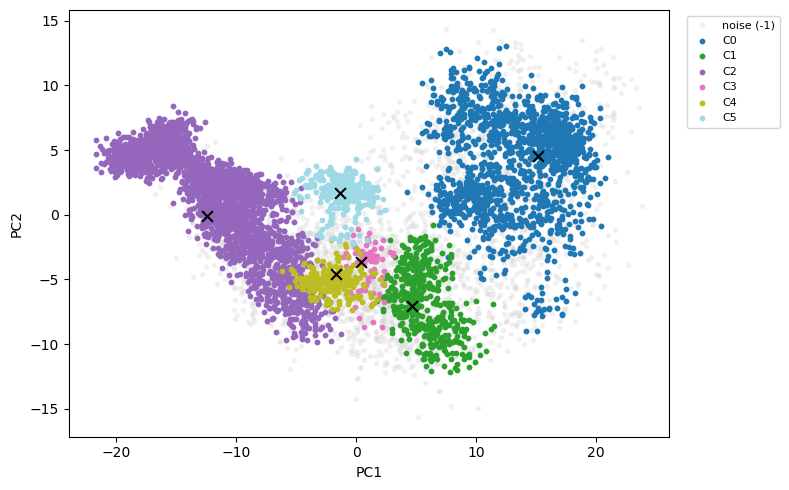

In [127]:
# HDBSCAN on MDA PCA version of pocket heavy non-BB resids
hdbscan_plot_pca(mda_Xpca[1], n_pcs_for_cluster=10, min_cluster_size=40, min_samples=None)


In [139]:
# # Using HDBSCAN (soft + medoids + optional writing)
# import numpy as np
# import matplotlib.pyplot as plt
# import hdbscan
# from hdbscan import all_points_membership_vectors
# import MDAnalysis as mda  # only needed if write_medoids=True

# def hdbscan_plot_pca(
#     Xpca,
#     n_pcs_for_cluster=10,
#     min_cluster_size=40,
#     min_samples=None,
#     metric='euclidean',
#     cluster_selection_method='eom',
#     cluster_selection_epsilon=None,   # e.g. 0.5..1.0 in PCA units if you want a looser split
#     plot_pcs=(0, 1),                  # which PCs to plot: (PC1, PC2) -> (0,1); PC2 vs PC3 -> (1,2)
#     fade_by_prob=True,                # fade points by membership probability
#     min_prob_for_medoid=0.6,          # pick medoids from confident core members
#     cmap_name='tab20',
#     point_size=10,
#     noise_alpha=0.25,
#     write_medoids=False,              # writes PDBs if True and meta/rep_trajs provided
#     meta=None,                        # array-like [(rep_id, frame_idx), ...] aligned with rows of Xpca
#     rep_trajs=None,                   # dict/list: rep_id -> (top_path, traj_path)
#     out_prefix='medoid_hdb'
# ):
#     """
#     Returns:
#       labels, probs, medoid_indices, clusterer, M
#         labels: np.ndarray (n_samples,), -1 = noise
#         probs:  np.ndarray (n_samples,), HDBSCAN membership probabilities
#         medoid_indices: dict {cluster_label: row_index}
#         clusterer: fitted HDBSCAN object
#         M: np.ndarray (n_samples, n_clusters) soft membership matrix (weights per cluster)
#     """
#     X = np.asarray(Xpca)
#     assert X.ndim == 2, "Xpca must be (n_samples, n_pcs)"
#     pc_i, pc_j = plot_pcs
#     assert max(pc_i, pc_j) < X.shape[1], "plot_pcs indices exceed available PCs"

#     # ---- clustering space (PC1..PCk) ----
#     Xc = X[:, :min(n_pcs_for_cluster, X.shape[1])]

#     # ---- HDBSCAN ----
#     clusterer = hdbscan.HDBSCAN(
#         min_cluster_size=min_cluster_size,
#         min_samples=min_samples,
#         metric=metric,
#         cluster_selection_method=cluster_selection_method,
#         cluster_selection_epsilon=0,
#         prediction_data=True
#     ).fit(Xc)

#     labels = clusterer.labels_               # -1 = noise
#     probs  = clusterer.probabilities_        # confidence of assigned cluster (0..1)
#     M      = all_points_membership_vectors(clusterer)  # soft memberships to all clusters

#     # ---- plot PC_i vs PC_j ----
#     fig, ax = plt.subplots(figsize=(8, 5))

#     # noise first (underneath)
#     noise = (labels == -1)
#     if noise.any():
#         ax.scatter(X[noise, pc_i], X[noise, pc_j],
#                    s=point_size, c='lightgrey', alpha=noise_alpha, zorder=1, label='Noise (-1)')

#     # clusters
#     uniq = [l for l in np.unique(labels) if l != -1]
#     cmap = plt.get_cmap(cmap_name, max(len(uniq), 1))
#     medoid_indices = {}

#     for i, lbl in enumerate(uniq):
#         m = (labels == lbl)

#         if fade_by_prob:
#             # per-point RGBA with alpha scaled by membership probability
#             base = np.array(cmap(i))
#             cols = np.tile(base, (m.sum(), 1))
#             cols[:, 3] = 0.25 + 0.75 * probs[m]  # 0.25..1.0
#             ax.scatter(X[m, pc_i], X[m, pc_j], s=point_size, color=cols, zorder=2, label=f'C{lbl}')
#         else:
#             ax.scatter(X[m, pc_i], X[m, pc_j], s=point_size, color=cmap(i), zorder=2, label=f'C{lbl}')

#         # medoid-like representative (closest to mean in clustering space), from confident core points
#         m_core = m & (probs >= min_prob_for_medoid) if min_prob_for_medoid > 0 else m
#         if not np.any(m_core):
#             m_core = m  # fallback if prob filter removes all

#         cluster_pts = Xc[m_core]
#         centroid = cluster_pts.mean(axis=0)
#         d = np.linalg.norm(cluster_pts - centroid, axis=1)
#         local_idx = np.argmin(d)
#         global_idx = np.flatnonzero(m_core)[local_idx]
#         medoid_indices[lbl] = global_idx

#         # mark medoid on plot
#         ax.scatter(X[global_idx, pc_i], X[global_idx, pc_j],
#                    marker='x', s=60, color='black', zorder=3)

#     ax.set_xlabel(f'PC{pc_i+1}')
#     ax.set_ylabel(f'PC{pc_j+1}')
#     ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
#     plt.tight_layout()

#     # ---- optional: write medoid structures ----
#     if write_medoids:
#         if meta is None or rep_trajs is None:
#             raise ValueError("To write medoids, pass both `meta` and `rep_trajs`.")
#         for lbl, row in medoid_indices.items():
#             rep_id, frame_idx = meta[row]  # ensure this maps 1:1 to X rows
#             top, traj = rep_trajs[rep_id]
#             u = mda.Universe(top, traj)

#             # adjust if you subsampled frames upstream; here we assume frame_idx is the actual index
#             f = int(frame_idx)
#             if f < 0: f = 0
#             if f >= len(u.trajectory): f = len(u.trajectory) - 1
#             u.trajectory[f]

#             out = f"{out_prefix}_C{lbl}_rep{rep_id}_frame{f}.pdb"
#             with mda.Writer(out) as W:
#                 W.write(u.atoms)
#             print("Wrote", out)

#     # return labels, probs, medoid_indices, clusterer, M


### Check if medoid frames are significantly different from eachother
Just recalculate the RMSD between PDB and medoid of the heavy atoms in the pocket of interest <br>
Need to have run `fillin_allchains.sh`

In [125]:
# # pdb_frame = os.path.join(path_to_fullprot_r1, "6edw_fix.pdb") # full protein 
# # u_pdb = mda.Universe(pdb_frame)

# # Select atoms heavy atoms 
# pdb_fp11_heavy = u_pdb.select_atoms(sel_fp11_AD_heavy)

# # medoids
# medoid0_path = os.path.join(path_to_cluster, "medoid_cluster0_fp11.pdb")
# medoid0_pdb = mda.Universe(medoid0_path)
# medoid0_fp11_heavy = medoid0_pdb.select_atoms(sel_fp11_AD_heavy)

# medoid1_path = os.path.join(path_to_cluster, "medoid_cluster1_fp11.pdb")
# medoid1_pdb = mda.Universe(medoid1_path)

# medoid2_path = os.path.join(path_to_cluster, "medoid_cluster2_fp11.pdb")
# medoid2_pdb = mda.Universe(medoid2_path)

# medoid3_path = os.path.join(path_to_cluster, "medoid_cluster3_fp11.pdb")
# medoid3_pdb = mda.Universe(medoid3_path)

# medoid4_path = os.path.join(path_to_cluster, "medoid_cluster4_fp11.pdb")
# medoid4_pdb = mda.Universe(medoid4_path)

# medoid5_path = os.path.join(path_to_cluster, "medoid_cluster5_fp11.pdb")
# medoid5_pdb = mda.Universe(medoid5_path)

In [127]:
# # Calculate RMSD on the pocket 
# # calc_rmsd(medoid0_pdb, pdb_fp11_heavy, f'{sel_fp11_AD_heavy}')
# r = mda.analysis.rms.RMSD(medoid0_pdb, pdb_fp11_heavy, f'{sel_fp11_AD_heavy}', superposition=False, center=False)
# r.run()
# print (f"RMSD: {r}")
